# 04 — Neural Training

Train Teacher/Student CNNs on log-mel features saved in data/processed/neural.
This notebook reads config/config.yaml, builds datasets per split using manifests, constructs CNNs per training.neural.* in the config, trains with callbacks, and evaluates on the test set.

In [1]:
# Imports
import os, json, yaml
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
sns.set_context('talk'); sns.set_style('whitegrid')


## Paths, config, and splits

In [2]:
def detect_root():
    cwd = Path.cwd()
    for p in [cwd, cwd.parent, cwd.parent.parent]:
        if all((p/d).exists() for d in ['config','data','scripts','notebooks']):
            return p
    return cwd
ROOT = detect_root()
CONFIG_PATH = ROOT/'config'/'config.yaml'
SPLITS_DIR = ROOT/'data'/'splits'
NEURAL_DIR  = ROOT/'data'/'processed'/'neural'
PLOTS_DIR = ROOT/'results'/'plots'; PLOTS_DIR.mkdir(parents=True, exist_ok=True)
EVALS_DIR = ROOT/'results'/'evaluations'; EVALS_DIR.mkdir(parents=True, exist_ok=True)
cfg = yaml.safe_load(open(CONFIG_PATH,'r'))
dcfg = cfg.get('config',{})
tcfg = cfg.get('training',{})
ncfg = tcfg.get('neural',{})
classes = dcfg.get('classes',[])
num_classes = len(classes)
classes


['angle_grinder', 'background_noise', 'power_tools']

## Data loading utilities

In [3]:
def read_manifest_stems(path: Path):
    stems=set()
    if not path.exists(): return stems
    for line in open(path,'r'):
        line=line.strip()
        if not line: continue
        rel,_ = line.split(',',1)
        stems.add(Path(rel).stem)
    return stems
split_idx = {
    'train': read_manifest_stems(SPLITS_DIR/'train.txt'),
    'val':   read_manifest_stems(SPLITS_DIR/'val.txt'),
    'test':  read_manifest_stems(SPLITS_DIR/'test.txt'),
}
def collect_neural_for_split(split_stems, class_names):
    X_list, y_list, paths = [], [], []
    name_to_idx = {c:i for i,c in enumerate(class_names)}
    for c in class_names:
        cdir = NEURAL_DIR/c
        if not cdir.exists(): continue
        for f in cdir.glob('*.npy'):
            base = f.stem.split('_seg')[0]
            if base in split_stems:
                arr = np.load(f)
                if arr.ndim==3: arr = np.transpose(arr, (1,2,0))  # [C,n_mels,T]→[n_mels,T,C]
                elif arr.ndim==2: arr = arr[:,:,None]
                else: continue
                X_list.append(arr.astype(np.float32))
                y_list.append(name_to_idx[c])
                paths.append(str(f))
    if not X_list: return np.empty((0,)), np.empty((0,),dtype=int), []
    X = np.stack(X_list, axis=0); y = np.array(y_list, dtype=int)
    return X, y, paths
X_train, y_train, _ = collect_neural_for_split(split_idx['train'], classes)
X_val,   y_val,   _ = collect_neural_for_split(split_idx['val'], classes)
X_test,  y_test,  _ = collect_neural_for_split(split_idx['test'], classes)
X_train.shape, X_val.shape, X_test.shape


((9270, 40, 101, 2), (1765, 40, 101, 2), (2201, 40, 101, 2))

## Build Teacher/Student CNNs

In [4]:
def build_teacher_cnn(input_shape, num_classes, cfg):
    filters = cfg.get('filters',[32,64,128,256])
    kernel  = cfg.get('kernel_size',[3,3,3,3])
    pool    = cfg.get('pool_size',[2,2,2,2])
    dropout = float(cfg.get('dropout',0.5))
    dense   = cfg.get('dense_units',[128,64])
    x_in = layers.Input(shape=input_shape); x = x_in
    for i,f in enumerate(filters):
        k = kernel[i] if i<len(kernel) else 3; p = pool[i] if i<len(pool) else 2
        x = layers.Conv2D(f,(k,k),padding='same')(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
        x = layers.MaxPool2D((p,p))(x); x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    for u in dense: x = layers.Dense(u, activation='relu')(x); x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(x_in, out, name='teacher_cnn')

def build_student_cnn(input_shape, num_classes, cfg):
    filters = cfg.get('filters',[16,32])
    kernel  = cfg.get('kernel_size',[3,3])
    pool    = cfg.get('pool_size',[2,2])
    dropout = float(cfg.get('dropout',0.3))
    dense   = cfg.get('dense_units',[64])
    x_in = layers.Input(shape=input_shape); x = x_in
    for i,f in enumerate(filters):
        k = kernel[i] if i<len(kernel) else 3; p = pool[i] if i<len(pool) else 2
        x = layers.Conv2D(f,(k,k),padding='same')(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
        x = layers.MaxPool2D((p,p))(x); x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    for u in dense: x = layers.Dense(u, activation='relu')(x); x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(x_in, out, name='student_cnn')


## Train and evaluate

Epoch 1/100
290/290 [==============================] - 22s 72ms/step - loss: 0.9277 - accuracy: 0.5319 - auc: 0.7228 - val_loss: 0.9056 - val_accuracy: 0.6782 - val_auc: 0.8475 - lr: 0.0010
Epoch 2/100
290/290 [==============================] - 20s 69ms/step - loss: 0.7489 - accuracy: 0.6356 - auc: 0.8120 - val_loss: 0.8529 - val_accuracy: 0.6952 - val_auc: 0.8415 - lr: 0.0010
Epoch 3/100
290/290 [==============================] - 20s 68ms/step - loss: 0.6954 - accuracy: 0.6689 - auc: 0.8406 - val_loss: 0.9016 - val_accuracy: 0.6550 - val_auc: 0.7690 - lr: 0.0010
Epoch 4/100
290/290 [==============================] - 20s 69ms/step - loss: 0.6568 - accuracy: 0.6972 - auc: 0.8605 - val_loss: 0.7432 - val_accuracy: 0.6408 - val_auc: 0.8459 - lr: 0.0010
Epoch 5/100
290/290 [==============================] - 24s 82ms/step - loss: 0.6305 - accuracy: 0.6699 - auc: 0.8662 - val_loss: 0.7216 - val_accuracy: 0.5972 - val_auc: 0.8485 - lr: 0.0010
Epoch 6/100
290/290 [=============================

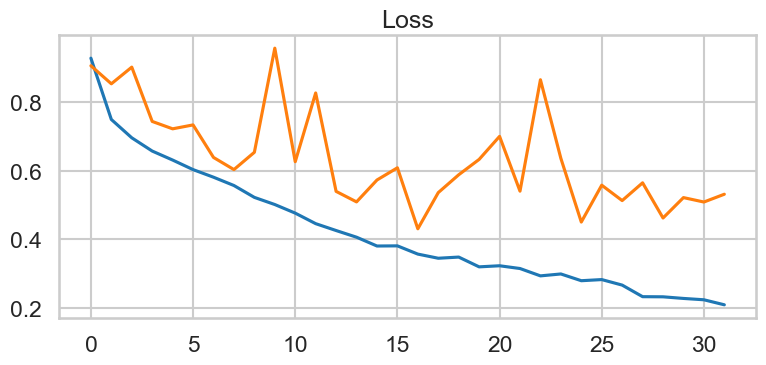

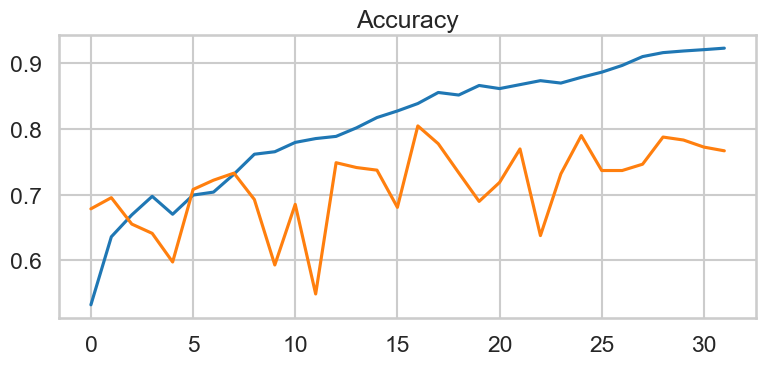

69/69 [==============================] - 1s 16ms/step
                  precision    recall  f1-score   support

   angle_grinder       0.49      0.91      0.64       437
background_noise       0.93      0.97      0.95      1015
     power_tools       0.85      0.38      0.53       749

        accuracy                           0.76      2201
       macro avg       0.76      0.75      0.71      2201
    weighted avg       0.82      0.76      0.74      2201



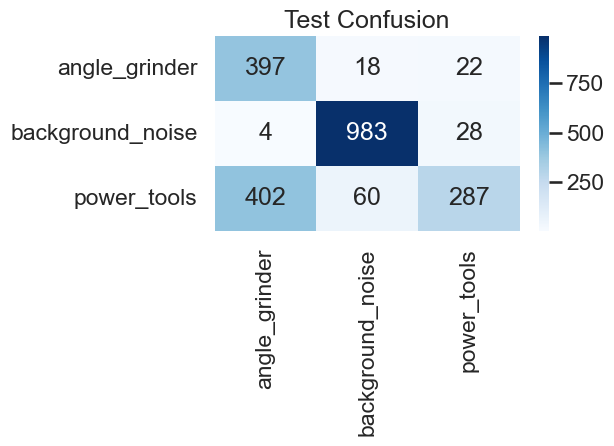

In [5]:
def class_weights(y, num_classes):
    c = np.bincount(y, minlength=num_classes); tot = c.sum()
    w = {i: (tot/(c[i] if c[i]>0 else 1)) for i in range(num_classes)}
    mw = np.mean(list(w.values())); return {k:v/mw for k,v in w.items()}

input_shape = X_train.shape[1:]
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes)
y_test_oh  = keras.utils.to_categorical(y_test, num_classes)
batch_size = int(tcfg.get('batch_size',32))
epochs = int(tcfg.get('epochs',100))
lr = float(tcfg.get('learning_rate',1e-3))
early_pat = int(tcfg.get('early_stopping_patience',15))
rlrop_pat = int(tcfg.get('reduce_lr_patience',10))
rlrop_fac = float(tcfg.get('reduce_lr_factor',0.5))
model = build_teacher_cnn(input_shape, num_classes, ncfg.get('teacher_cnn',{}))
model.compile(optimizer=keras.optimizers.Adam(lr), loss='categorical_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
cws = class_weights(y_train, num_classes)
cbs = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=early_pat, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=rlrop_fac, patience=rlrop_pat, verbose=1),
]
hist = model.fit(X_train, y_train_oh, validation_data=(X_val, y_val_oh), epochs=epochs, batch_size=batch_size, callbacks=cbs, class_weight=cws, verbose=1)
# Plots
plt.figure(figsize=(8,4)); plt.plot(hist.history['loss']); plt.plot(hist.history['val_loss']); plt.title('Loss'); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4)); plt.plot(hist.history['accuracy']); plt.plot(hist.history['val_accuracy']); plt.title('Accuracy'); plt.tight_layout(); plt.show()
# Test evaluation
y_pred = np.argmax(model.predict(X_test, batch_size=batch_size), axis=1)
print(classification_report(y_test, y_pred, target_names=classes, output_dict=False))
cm = confusion_matrix(y_test, y_pred, labels=list(range(num_classes)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes); plt.title('Test Confusion'); plt.tight_layout(); plt.show()
